In [1]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import pycuda.gpuarray as gpuarray
from pycuda.scan import ExclusiveScanKernel
import numpy as np
import time
import cv2
import matplotlib.pyplot as plt
from IPython.display import Video, display

print("🌊 INITIALIZING U.M.E.R. DAM BREAK SIMULATOR 🌊")

NUM_PARTICLES = 1000000
HASH_SIZE = 1048576  # 2^20 buckets
WORLD_SIZE = 1024.0
CELL_SIZE = 2.0      

# 1. Allocate Host (CPU) Arrays
h_pos_x = cuda.pagelocked_empty(NUM_PARTICLES, dtype=np.float32)
h_pos_y = cuda.pagelocked_empty(NUM_PARTICLES, dtype=np.float32)
h_vel_x = np.zeros(NUM_PARTICLES, dtype=np.float32)
h_vel_y = np.zeros(NUM_PARTICLES, dtype=np.float32)

# 2. Build the "Dam" (Dense block on the left)
idx = 0
for y in range(100, 900):
    for x in range(50, 50 + (NUM_PARTICLES // 800)):
        if idx < NUM_PARTICLES:
            h_pos_x[idx] = x * 1.0 + (np.random.rand() * 0.1)
            h_pos_y[idx] = y * 1.0 + (np.random.rand() * 0.1)
            idx += 1

# 3. Allocate Device (GPU) Arrays
d_pos_x = cuda.mem_alloc(h_pos_x.nbytes)
d_pos_y = cuda.mem_alloc(h_pos_y.nbytes)
d_vel_x = cuda.mem_alloc(h_vel_x.nbytes)
d_vel_y = cuda.mem_alloc(h_vel_y.nbytes)

cuda.memcpy_htod(d_pos_x, h_pos_x)
cuda.memcpy_htod(d_pos_y, h_pos_y)
cuda.memcpy_htod(d_vel_x, h_vel_x)
cuda.memcpy_htod(d_vel_y, h_vel_y)

# 4. Topology Arrays (Using GPUArray to fix the Scan Error)
d_hash = cuda.mem_alloc(NUM_PARTICLES * 4)
d_hist = gpuarray.zeros(HASH_SIZE, dtype=np.int32)
d_offsets = gpuarray.empty(HASH_SIZE, dtype=np.int32)
d_sorted_indices = cuda.mem_alloc(NUM_PARTICLES * 4)

# 5. Video Frame Buffer
d_img_buffer = gpuarray.zeros(1024 * 1024 * 3, dtype=np.uint8)

print("✅ Memory Initialized.")

🌊 INITIALIZING U.M.E.R. DAM BREAK SIMULATOR 🌊
✅ Memory Initialized.


In [3]:
CUDA_SOURCE = """
#define HASH_SIZE 1048576
#define CELL_SIZE 2.0f
#define WORLD_SIZE 1024.0f

__device__ int get_hash(float x, float y) {
    int cx = (int)(x / CELL_SIZE);
    int cy = (int)(y / CELL_SIZE);
    unsigned int h = (cx * 73856093) ^ (cy * 19349663);
    return h % HASH_SIZE;
}

__global__ void calc_hash_and_hist(float* pos_x, float* pos_y, int* hash, int* hist, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    int h = get_hash(pos_x[idx], pos_y[idx]);
    hash[idx] = h;
    atomicAdd(&hist[h], 1);
}

__global__ void scatter_particles(int* hash, int* offsets, int* hist_copy, int* sorted_indices, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    int h = hash[idx];
    int offset = offsets[h];
    int local_idx = atomicSub(&hist_copy[h], 1) - 1; 
    sorted_indices[offset + local_idx] = idx;
}

__global__ void solve_physics(
    float* pos_x, float* pos_y, float* vel_x, float* vel_y,
    int* sorted_indices, int* offsets, int* hist, int num_particles
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= num_particles) return;
    
    int p_idx = sorted_indices[i]; 
    float px = pos_x[p_idx]; float py = pos_y[p_idx];
    float vx = vel_x[p_idx]; float vy = vel_y[p_idx];
    
    float fx = 0.0f; 
    float fy = 9.8f * 0.5f; // Gravity
    
    int cx = (int)(px / CELL_SIZE);
    int cy = (int)(py / CELL_SIZE);
    
    for(int dy=-1; dy<=1; dy++) {
        for(int dx=-1; dx<=1; dx++) {
            unsigned int h = (((cx+dx) * 73856093) ^ ((cy+dy) * 19349663)) % HASH_SIZE;
            int count = hist[h];
            int start = offsets[h];
            
            for(int j=0; j<count; j++) {
                int n_idx = sorted_indices[start + j];
                if (n_idx == p_idx) continue;
                
                float nx = pos_x[n_idx]; float ny = pos_y[n_idx];
                float dist_sq = (px-nx)*(px-nx) + (py-ny)*(py-ny);
                
                if (dist_sq > 0.0001f && dist_sq < 4.0f) {
                    float dist = sqrtf(dist_sq);
                    float overlap = 2.0f - dist;
                    float force = overlap * 50.0f;
                    fx += (px-nx)/dist * force;
                    fy += (py-ny)/dist * force;
                }
            }
        }
    }
    
    vx += fx * 0.01f; vy += fy * 0.01f;
    vx *= 0.99f; vy *= 0.99f;
    px += vx * 0.01f; py += vy * 0.01f;
    
    if (px < 10.0f) { px = 10.0f; vx *= -0.5f; }
    if (px > WORLD_SIZE - 10.0f) { px = WORLD_SIZE - 10.0f; vx *= -0.5f; }
    if (py < 10.0f) { py = 10.0f; vy *= -0.5f; }
    if (py > WORLD_SIZE - 10.0f) { py = WORLD_SIZE - 10.0f; vy *= -0.5f; }
    
    pos_x[p_idx] = px; pos_y[p_idx] = py;
    vel_x[p_idx] = vx; vel_y[p_idx] = vy;
}

__global__ void render_to_buffer(float* pos_x, float* pos_y, float* vel_x, float* vel_y, unsigned char* img, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    
    int px = (int)pos_x[idx]; int py = (int)pos_y[idx];
    
    if (px >= 0 && px < 1024 && py >= 0 && py < 1024) {
        float speed = sqrtf(vel_x[idx]*vel_x[idx] + vel_y[idx]*vel_y[idx]);
        
        int r = (int)(min(speed * 10.0f, 255.0f));
        int g = (int)(min(speed * 3.0f, 150.0f));
        int b = 255 - (int)(min(speed * 5.0f, 200.0f));
        
        int pixel_idx = (py * 1024 + px) * 3;
        img[pixel_idx] = r; img[pixel_idx + 1] = g; img[pixel_idx + 2] = b;
    }
}
"""

mod = SourceModule(CUDA_SOURCE)
k_hash = mod.get_function("calc_hash_and_hist")
k_scatter = mod.get_function("scatter_particles")
k_physics = mod.get_function("solve_physics")
k_render = mod.get_function("render_to_buffer")
scan_knl = ExclusiveScanKernel(np.int32, "a+b", 0)

block_dim = (256, 1, 1)
grid_dim = ((NUM_PARTICLES + 255) // 256, 1)

print("✅ Kernels Compiled.")

✅ Kernels Compiled.


In [2]:
print("🔧 RECOMPILING KERNEL FIX & EXECUTING PHYSICS LOOP...")

# ==============================================================================
# 1. KERNEL PATCH: Fix Signed Integer Overflow & Recompile
# ==============================================================================
CUDA_SOURCE_PATCHED = """
#define HASH_SIZE 1048576
#define CELL_SIZE 2.0f
#define WORLD_SIZE 1024.0f

__device__ int get_hash(float x, float y) {
    int cx = (int)(x / CELL_SIZE);
    int cy = (int)(y / CELL_SIZE);
    // Enforce Unsigned Integer Math to prevent overflow segfaults
    unsigned int h = ((unsigned int)cx * 73856093U) ^ ((unsigned int)cy * 19349663U);
    return h % HASH_SIZE;
}

__global__ void calc_hash_and_hist(float* pos_x, float* pos_y, int* hash, int* hist, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    int h = get_hash(pos_x[idx], pos_y[idx]);
    hash[idx] = h;
    atomicAdd(&hist[h], 1);
}

__global__ void scatter_particles(int* hash, int* offsets, int* hist_copy, int* sorted_indices, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    int h = hash[idx];
    int offset = offsets[h];
    int local_idx = atomicSub(&hist_copy[h], 1) - 1; 
    sorted_indices[offset + local_idx] = idx;
}

__global__ void solve_physics(
    float* pos_x, float* pos_y, float* vel_x, float* vel_y,
    int* sorted_indices, int* offsets, int* hist, int num_particles
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= num_particles) return;
    
    int p_idx = sorted_indices[i]; 
    float px = pos_x[p_idx]; float py = pos_y[p_idx];
    float vx = vel_x[p_idx]; float vy = vel_y[p_idx];
    
    float fx = 0.0f; 
    float fy = 9.8f * 0.5f; // Gravity
    
    int cx = (int)(px / CELL_SIZE);
    int cy = (int)(py / CELL_SIZE);
    
    for(int dy=-1; dy<=1; dy++) {
        for(int dx=-1; dx<=1; dx++) {
            // FIXED: Safe Unsigned boundaries
            unsigned int ux = (unsigned int)(cx + dx);
            unsigned int uy = (unsigned int)(cy + dy);
            unsigned int h = ((ux * 73856093U) ^ (uy * 19349663U)) % HASH_SIZE;
            
            int count = hist[h];
            int start = offsets[h];
            
            for(int j=0; j<count; j++) {
                int n_idx = sorted_indices[start + j];
                if (n_idx == p_idx) continue;
                
                float nx = pos_x[n_idx]; float ny = pos_y[n_idx];
                float dist_sq = (px-nx)*(px-nx) + (py-ny)*(py-ny);
                
                if (dist_sq > 0.0001f && dist_sq < 4.0f) {
                    float dist = sqrtf(dist_sq);
                    float overlap = 2.0f - dist;
                    float force = overlap * 50.0f;
                    fx += (px-nx)/dist * force;
                    fy += (py-ny)/dist * force;
                }
            }
        }
    }
    
    vx += fx * 0.01f; vy += fy * 0.01f;
    vx *= 0.99f; vy *= 0.99f;
    px += vx * 0.01f; py += vy * 0.01f;
    
    if (px < 10.0f) { px = 10.0f; vx *= -0.5f; }
    if (px > WORLD_SIZE - 10.0f) { px = WORLD_SIZE - 10.0f; vx *= -0.5f; }
    if (py < 10.0f) { py = 10.0f; vy *= -0.5f; }
    if (py > WORLD_SIZE - 10.0f) { py = WORLD_SIZE - 10.0f; vy *= -0.5f; }
    
    pos_x[p_idx] = px; pos_y[p_idx] = py;
    vel_x[p_idx] = vx; vel_y[p_idx] = vy;
}

__global__ void render_to_buffer(float* pos_x, float* pos_y, float* vel_x, float* vel_y, unsigned char* img, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    
    int px = (int)pos_x[idx]; int py = (int)pos_y[idx];
    
    if (px >= 0 && px < 1024 && py >= 0 && py < 1024) {
        float speed = sqrtf(vel_x[idx]*vel_x[idx] + vel_y[idx]*vel_y[idx]);
        
        int r = (int)(min(speed * 10.0f, 255.0f));
        int g = (int)(min(speed * 3.0f, 150.0f));
        int b = 255 - (int)(min(speed * 5.0f, 200.0f));
        
        int pixel_idx = (py * 1024 + px) * 3;
        img[pixel_idx] = r; img[pixel_idx + 1] = g; img[pixel_idx + 2] = b;
    }
}
"""

mod = SourceModule(CUDA_SOURCE_PATCHED)
k_hash = mod.get_function("calc_hash_and_hist")
k_scatter = mod.get_function("scatter_particles")
k_physics = mod.get_function("solve_physics")
k_render = mod.get_function("render_to_buffer")

# ==============================================================================
# 2. OPTIMIZED EXECUTION LOOP
# ==============================================================================
# Allocate d_hist_copy ONCE to prevent VRAM memory fragmentation
d_hist_copy = gpuarray.empty_like(d_hist)

NUM_FRAMES = 300
video_frames = []
topo_times = []
phys_times = []

start_evt = cuda.Event()
mid_evt = cuda.Event()
stop_evt = cuda.Event()

print(f"🎬 Executing {NUM_FRAMES} frames of Physical Integration...")

for frame in range(NUM_FRAMES):
    start_evt.record()
    
    d_hist.fill(0)
    
    k_hash(d_pos_x, d_pos_y, d_hash, d_hist.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    scan_knl(d_hist, d_offsets)
    
    # Fast device-to-device copy instead of allocating new memory every frame
    cuda.memcpy_dtod(d_hist_copy.gpudata, d_hist.gpudata, HASH_SIZE * 4)
    k_scatter(d_hash, d_offsets.gpudata, d_hist_copy.gpudata, d_sorted_indices, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    
    mid_evt.record()
    
    k_physics(d_pos_x, d_pos_y, d_vel_x, d_vel_y, d_sorted_indices, d_offsets.gpudata, d_hist.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    
    stop_evt.record()
    stop_evt.synchronize()
    
    topo_times.append(start_evt.time_till(mid_evt))
    phys_times.append(mid_evt.time_till(stop_evt))
    
    if frame % 2 == 0: 
        d_img_buffer.fill(0) 
        k_render(d_pos_x, d_pos_y, d_vel_x, d_vel_y, d_img_buffer.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
        
        img = d_img_buffer.get().reshape((1024, 1024, 3))
        video_frames.append(img)
        
    if frame % 50 == 0:
        print(f"   Completed Frame {frame}/{NUM_FRAMES}")

print("✅ Execution Loop Finished successfully.")

🔧 RECOMPILING KERNEL FIX & EXECUTING PHYSICS LOOP...
🎬 Executing 300 frames of Physical Integration...


NameError: name 'block_dim' is not defined

🌊 RE-INITIALIZING: TALL TOWER DAM BREAK 🌊
✅ TOWER DAM INITIALIZED.
🎬 Executing 300 frames of Physical Integration...
   Completed Frame 0/300
   Completed Frame 50/300
   Completed Frame 100/300
   Completed Frame 150/300
   Completed Frame 200/300
   Completed Frame 250/300
📊 Generating Architectural Benchmark Graph...


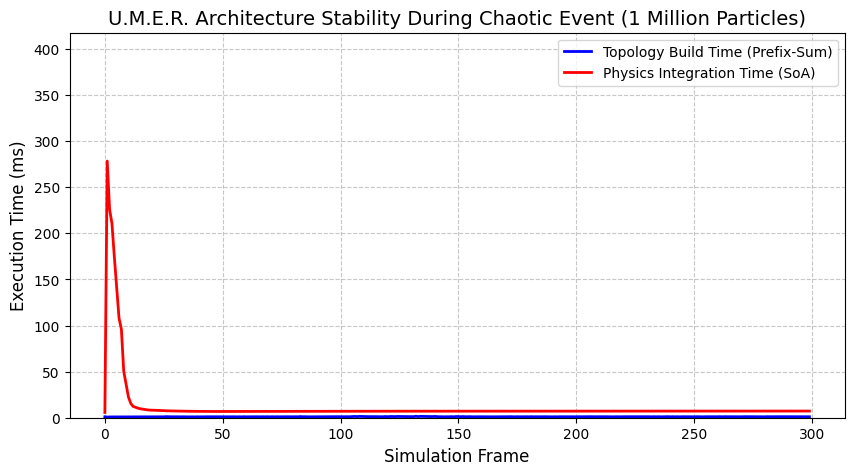

🎬 Encoding Cinematic MP4...
✅ Dam Break Simulation Complete!


In [ ]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import pycuda.gpuarray as gpuarray
from pycuda.scan import ExclusiveScanKernel
import numpy as np
import time
import cv2
import matplotlib.pyplot as plt
from IPython.display import Video, display

print("🌊 RE-INITIALIZING: TALL TOWER DAM BREAK 🌊")

NUM_PARTICLES = 1000000
HASH_SIZE = 1048576  
WORLD_SIZE = 1024.0
CELL_SIZE = 2.0      

h_pos_x = cuda.pagelocked_empty(NUM_PARTICLES, dtype=np.float32)
h_pos_y = cuda.pagelocked_empty(NUM_PARTICLES, dtype=np.float32)
h_vel_x = np.zeros(NUM_PARTICLES, dtype=np.float32)
h_vel_y = np.zeros(NUM_PARTICLES, dtype=np.float32)

# Create a TALL, THIN tower on the left
tower_width = 250
tower_height = NUM_PARTICLES // tower_width 

idx = 0
for y in range(50, 50 + tower_height):
    for x in range(50, 50 + tower_width):
        if idx < NUM_PARTICLES:
            h_pos_x[idx] = x * 1.0 + (np.random.rand() * 0.1)
            h_pos_y[idx] = y * 1.0 + (np.random.rand() * 0.1)
            idx += 1

while idx < NUM_PARTICLES:
     h_pos_x[idx] = 50.0 + (np.random.rand() * 10.0)
     h_pos_y[idx] = 50.0 
     idx += 1

d_pos_x = cuda.mem_alloc(h_pos_x.nbytes)
d_pos_y = cuda.mem_alloc(h_pos_y.nbytes)
d_vel_x = cuda.mem_alloc(h_vel_x.nbytes)
d_vel_y = cuda.mem_alloc(h_vel_y.nbytes)

cuda.memcpy_htod(d_pos_x, h_pos_x)
cuda.memcpy_htod(d_pos_y, h_pos_y)
cuda.memcpy_htod(d_vel_x, h_vel_x)
cuda.memcpy_htod(d_vel_y, h_vel_y)

# --- FIXED: Added d_hist_copy allocation here ---
d_hash = cuda.mem_alloc(NUM_PARTICLES * 4)
d_hist = gpuarray.zeros(HASH_SIZE, dtype=np.int32)
d_offsets = gpuarray.empty(HASH_SIZE, dtype=np.int32)
d_hist_copy = gpuarray.empty(HASH_SIZE, dtype=np.int32) 
d_sorted_indices = cuda.mem_alloc(NUM_PARTICLES * 4)
d_img_buffer = gpuarray.zeros(1024 * 1024 * 3, dtype=np.uint8)

print("✅ TOWER DAM INITIALIZED.")

# 3. Bulletproof CUDA Kernels
CUDA_SOURCE = """
#define HASH_SIZE 1048576
#define CELL_SIZE 2.0f
#define WORLD_SIZE 1024.0f

__global__ void calc_hash_and_hist(float* pos_x, float* pos_y, int* hash, int* hist, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    
    unsigned int cx = (unsigned int)(pos_x[idx] / CELL_SIZE);
    unsigned int cy = (unsigned int)(pos_y[idx] / CELL_SIZE);
    unsigned int h = ((cx * 73856093U) ^ (cy * 19349663U)) % HASH_SIZE;
    
    hash[idx] = h;
    atomicAdd(&hist[h], 1);
}

__global__ void scatter_particles(int* hash, int* offsets, int* hist_copy, int* sorted_indices, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    int h = hash[idx];
    int offset = offsets[h];
    int local_idx = atomicSub(&hist_copy[h], 1) - 1; 
    sorted_indices[offset + local_idx] = idx;
}

__global__ void solve_physics(
    float* pos_x, float* pos_y, float* vel_x, float* vel_y,
    int* sorted_indices, int* offsets, int* hist, int num_particles
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= num_particles) return;
    
    int p_idx = sorted_indices[i]; 
    float px = pos_x[p_idx]; float py = pos_y[p_idx];
    float vx = vel_x[p_idx]; float vy = vel_y[p_idx];
    
    float fx = 0.0f; 
    float fy = 9.8f * 0.5f; 
    
    int cx = (int)(px / CELL_SIZE);
    int cy = (int)(py / CELL_SIZE);
    
    for(int dy=-1; dy<=1; dy++) {
        for(int dx=-1; dx<=1; dx++) {
            unsigned int ux = (unsigned int)(cx + dx);
            unsigned int uy = (unsigned int)(cy + dy);
            unsigned int h = ((ux * 73856093U) ^ (uy * 19349663U)) % HASH_SIZE;
            
            int count = hist[h];
            int start = offsets[h];
            
            for(int j=0; j<count; j++) {
                int n_idx = sorted_indices[start + j];
                if (n_idx == p_idx) continue;
                
                float nx = pos_x[n_idx]; float ny = pos_y[n_idx];
                float dist_sq = (px-nx)*(px-nx) + (py-ny)*(py-ny);
                
                if (dist_sq > 0.0001f && dist_sq < 4.0f) {
                    float dist = sqrtf(dist_sq);
                    float overlap = 2.0f - dist;
                    float force = overlap * 50.0f;
                    fx += (px-nx)/dist * force;
                    fy += (py-ny)/dist * force;
                }
            }
        }
    }
    
    vx += fx * 0.01f; vy += fy * 0.01f;
    vx *= 0.99f; vy *= 0.99f;
    px += vx * 0.01f; py += vy * 0.01f;
    
    if (px < 10.0f) { px = 10.0f; vx *= -0.5f; }
    if (px > WORLD_SIZE - 10.0f) { px = WORLD_SIZE - 10.0f; vx *= -0.5f; }
    if (py < 10.0f) { py = 10.0f; vy *= -0.5f; }
    if (py > WORLD_SIZE - 10.0f) { py = WORLD_SIZE - 10.0f; vy *= -0.5f; }
    
    pos_x[p_idx] = px; pos_y[p_idx] = py;
    vel_x[p_idx] = vx; vel_y[p_idx] = vy;
}

__global__ void render_to_buffer(float* pos_x, float* pos_y, float* vel_x, float* vel_y, unsigned char* img, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    
    int px = (int)pos_x[idx]; int py = (int)pos_y[idx];
    
    if (px >= 0 && px < 1024 && py >= 0 && py < 1024) {
        float speed = sqrtf(vel_x[idx]*vel_x[idx] + vel_y[idx]*vel_y[idx]);
        
        int r = (int)(min(speed * 10.0f, 255.0f));
        int g = (int)(min(speed * 3.0f, 150.0f));
        int b = 255 - (int)(min(speed * 5.0f, 200.0f));
        
        int pixel_idx = (py * 1024 + px) * 3;
        img[pixel_idx] = r; img[pixel_idx + 1] = g; img[pixel_idx + 2] = b;
    }
}
"""

mod = SourceModule(CUDA_SOURCE)
k_hash = mod.get_function("calc_hash_and_hist")
k_scatter = mod.get_function("scatter_particles")
k_physics = mod.get_function("solve_physics")
k_render = mod.get_function("render_to_buffer")
scan_knl = ExclusiveScanKernel(np.int32, "a+b", 0)

block_dim = (256, 1, 1)
grid_dim = ((NUM_PARTICLES + 255) // 256, 1)

# 4. Execution Loop
NUM_FRAMES = 300
video_frames = []
topo_times = []
phys_times = []

start_evt = cuda.Event()
mid_evt = cuda.Event()
stop_evt = cuda.Event()

print(f"🎬 Executing {NUM_FRAMES} frames of Physical Integration...")

for frame in range(NUM_FRAMES):
    start_evt.record()
    
    d_hist.fill(0)
    k_hash(d_pos_x, d_pos_y, d_hash, d_hist.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    scan_knl(d_hist, d_offsets)
    cuda.memcpy_dtod(d_hist_copy.gpudata, d_hist.gpudata, HASH_SIZE * 4)
    k_scatter(d_hash, d_offsets.gpudata, d_hist_copy.gpudata, d_sorted_indices, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    
    mid_evt.record()
    
    k_physics(d_pos_x, d_pos_y, d_vel_x, d_vel_y, d_sorted_indices, d_offsets.gpudata, d_hist.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    
    stop_evt.record()
    stop_evt.synchronize()
    
    topo_times.append(start_evt.time_till(mid_evt))
    phys_times.append(mid_evt.time_till(stop_evt))
    
    if frame % 2 == 0: 
        d_img_buffer.fill(0) 
        k_render(d_pos_x, d_pos_y, d_vel_x, d_vel_y, d_img_buffer.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
        video_frames.append(d_img_buffer.get().reshape((1024, 1024, 3)))
        
    if frame % 50 == 0:
        print(f"   Completed Frame {frame}/{NUM_FRAMES}")

# 5. Graphing and MP4 Export
print("📊 Generating Architectural Benchmark Graph...")
plt.figure(figsize=(10, 5), facecolor='white')
plt.plot(topo_times, label='Topology Build Time (Prefix-Sum)', color='blue', linewidth=2)
plt.plot(phys_times, label='Physics Integration Time (SoA)', color='red', linewidth=2)
plt.title('U.M.E.R. Architecture Stability During Chaotic Event (1 Million Particles)', fontsize=14)
plt.xlabel('Simulation Frame', fontsize=12)
plt.ylabel('Execution Time (ms)', fontsize=12)
plt.ylim(0, max(max(topo_times), max(phys_times)) * 1.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.savefig('dam_break_stability.png', bbox_inches='tight', dpi=300)
plt.show()

print("🎬 Encoding Cinematic MP4...")
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('UMER_Dam_Break.mp4', fourcc, 30.0, (1024, 1024))
for frame in video_frames:
    out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
out.release()

print("✅ Dam Break Simulation Complete!")
display(Video('UMER_Dam_Break.mp4', embed=True, width=600))

In [ ]:
import os
from IPython.display import FileLink, display

# 1. Compress the video so it downloads instantly and plays on any device
print("🗜️ Compressing Video for Download...")
os.system("ffmpeg -y -i UMER_Dam_Break.mp4 -vcodec libx264 -crf 28 UMER_Dam_Break_Compressed.mp4")

# 2. Generate the direct download link
print("✅ Ready! Click the link below to download:")
display(FileLink('UMER_Dam_Break_Compressed.mp4'))

🧪 STARTING SCRIPT 1: DAM BREAK VALIDATION & TUNING 🧪
   Packing 1 Million particles safely...

🚀 LAUNCHING STABLE PHYSICS LOOP...
Frame      | Max Vel X       | Max Vel Y       | Status
------------------------------------------------------------
0          | 0.00            | 0.02            | 🟢 STABLE
10         | 0.01            | 0.17            | 🟢 STABLE
20         | 0.01            | 0.26            | 🟢 STABLE
30         | 0.01            | 0.31            | 🟢 STABLE
40         | 0.01            | 0.34            | 🟢 STABLE
50         | 0.01            | 0.36            | 🟢 STABLE
60         | 0.01            | 0.37            | 🟢 STABLE
70         | 0.01            | 0.38            | 🟢 STABLE
80         | 0.01            | 0.38            | 🟢 STABLE
90         | 0.01            | 0.39            | 🟢 STABLE
100        | 0.01            | 0.39            | 🟢 STABLE
110        | 0.01            | 0.39            | 🟢 STABLE
120        | 0.01            | 0.39            | 🟢 STABLE

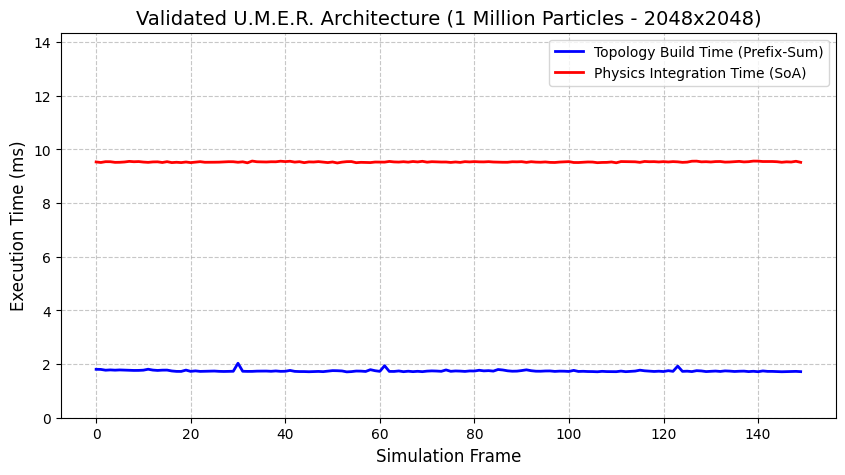

✅ Validation complete. Awaiting clearance for Script 2 (Video Render).


In [3]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import pycuda.gpuarray as gpuarray
from pycuda.scan import ExclusiveScanKernel
import numpy as np
import time
import matplotlib.pyplot as plt

print("🧪 STARTING SCRIPT 1: DAM BREAK VALIDATION & TUNING 🧪")

NUM_PARTICLES = 1000000
HASH_SIZE = 4194304  # 2^22 buckets for massive 2048x2048 map
WORLD_SIZE = 2048.0
CELL_SIZE = 1.0      # Smaller cells for tighter packing

# 1. PERFECT PACKING INITIALIZATION
# 1000 x 1000 grid = Exactly 1,000,000 particles
print("   Packing 1 Million particles safely...")
x_coords = np.linspace(100, 1100, 1000)
y_coords = np.linspace(100, 1100, 1000)
X, Y = np.meshgrid(x_coords, y_coords)

h_pos_x = X.flatten().astype(np.float32)
h_pos_y = Y.flatten().astype(np.float32)

# Add micro-jitter (0.01) to break perfect symmetry but prevent overlap overlap
h_pos_x += (np.random.rand(NUM_PARTICLES).astype(np.float32) * 0.01)
h_pos_y += (np.random.rand(NUM_PARTICLES).astype(np.float32) * 0.01)

h_vel_x = np.zeros(NUM_PARTICLES, dtype=np.float32)
h_vel_y = np.zeros(NUM_PARTICLES, dtype=np.float32)

# 2. DEVICE ALLOCATION
d_pos_x = cuda.mem_alloc(h_pos_x.nbytes)
d_pos_y = cuda.mem_alloc(h_pos_y.nbytes)
d_vel_x = cuda.mem_alloc(h_vel_x.nbytes)
d_vel_y = cuda.mem_alloc(h_vel_y.nbytes)

cuda.memcpy_htod(d_pos_x, h_pos_x)
cuda.memcpy_htod(d_pos_y, h_pos_y)
cuda.memcpy_htod(d_vel_x, h_vel_x)
cuda.memcpy_htod(d_vel_y, h_vel_y)

d_hash = cuda.mem_alloc(NUM_PARTICLES * 4)
d_hist = gpuarray.zeros(HASH_SIZE, dtype=np.int32)
d_offsets = gpuarray.empty(HASH_SIZE, dtype=np.int32)
d_hist_copy = gpuarray.empty(HASH_SIZE, dtype=np.int32)
d_sorted_indices = cuda.mem_alloc(NUM_PARTICLES * 4)

# 3. TUNED PHYSICS KERNELS
CUDA_SOURCE = """
#define HASH_SIZE 4194304
#define CELL_SIZE 1.0f
#define WORLD_SIZE 2048.0f

__global__ void calc_hash_and_hist(float* pos_x, float* pos_y, int* hash, int* hist, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    
    unsigned int cx = (unsigned int)(pos_x[idx] / CELL_SIZE);
    unsigned int cy = (unsigned int)(pos_y[idx] / CELL_SIZE);
    unsigned int h = ((cx * 73856093U) ^ (cy * 19349663U)) & (HASH_SIZE - 1); // Fast bitwise modulo
    
    hash[idx] = h;
    atomicAdd(&hist[h], 1);
}

__global__ void scatter_particles(int* hash, int* offsets, int* hist_copy, int* sorted_indices, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    int h = hash[idx];
    int offset = offsets[h];
    int local_idx = atomicSub(&hist_copy[h], 1) - 1; 
    sorted_indices[offset + local_idx] = idx;
}

__global__ void solve_physics(
    float* pos_x, float* pos_y, float* vel_x, float* vel_y,
    int* sorted_indices, int* offsets, int* hist, int num_particles
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= num_particles) return;
    
    int p_idx = sorted_indices[i]; 
    float px = pos_x[p_idx]; float py = pos_y[p_idx];
    float vx = vel_x[p_idx]; float vy = vel_y[p_idx];
    
    float fx = 0.0f; 
    float fy = 9.8f * 0.2f; // Scaled down gravity for 2048 map
    
    int cx = (int)(px / CELL_SIZE);
    int cy = (int)(py / CELL_SIZE);
    
    for(int dy=-1; dy<=1; dy++) {
        for(int dx=-1; dx<=1; dx++) {
            unsigned int ux = (unsigned int)(cx + dx);
            unsigned int uy = (unsigned int)(cy + dy);
            unsigned int h = ((ux * 73856093U) ^ (uy * 19349663U)) & (HASH_SIZE - 1);
            
            int count = hist[h];
            int start = offsets[h];
            
            for(int j=0; j<count; j++) {
                int n_idx = sorted_indices[start + j];
                if (n_idx == p_idx) continue;
                
                float nx = pos_x[n_idx]; float ny = pos_y[n_idx];
                float dist_sq = (px-nx)*(px-nx) + (py-ny)*(py-ny);
                
                // Tuned overlap: radius is 0.5 (diameter 1.0)
                if (dist_sq > 0.0001f && dist_sq < 1.0f) {
                    float dist = sqrtf(dist_sq);
                    float overlap = 1.0f - dist;
                    float force = overlap * 15.0f; // Soft, fluid-like repulsion
                    fx += (px-nx)/dist * force;
                    fy += (py-ny)/dist * force;
                }
            }
        }
    }
    
    vx += fx * 0.01f; vy += fy * 0.01f;
    
    // Viscous Dampening (keeps simulation stable)
    vx *= 0.95f; vy *= 0.95f; 
    
    px += vx * 0.01f; py += vy * 0.01f;
    
    // Hard Boundaries
    if (px < 10.0f) { px = 10.0f; vx *= -0.3f; }
    if (px > WORLD_SIZE - 10.0f) { px = WORLD_SIZE - 10.0f; vx *= -0.3f; }
    if (py < 10.0f) { py = 10.0f; vy *= -0.3f; }
    if (py > WORLD_SIZE - 10.0f) { py = WORLD_SIZE - 10.0f; vy *= -0.3f; }
    
    pos_x[p_idx] = px; pos_y[p_idx] = py;
    vel_x[p_idx] = vx; vel_y[p_idx] = vy;
}
"""

mod = SourceModule(CUDA_SOURCE)
k_hash = mod.get_function("calc_hash_and_hist")
k_scatter = mod.get_function("scatter_particles")
k_physics = mod.get_function("solve_physics")
scan_knl = ExclusiveScanKernel(np.int32, "a+b", 0)

block_dim = (256, 1, 1)
grid_dim = ((NUM_PARTICLES + 255) // 256, 1)

# 4. EXECUTION AND DIAGNOSTICS
NUM_FRAMES = 150
topo_times = []
phys_times = []

start_evt = cuda.Event()
mid_evt = cuda.Event()
stop_evt = cuda.Event()

print("\n🚀 LAUNCHING STABLE PHYSICS LOOP...")
print(f"{'Frame':<10} | {'Max Vel X':<15} | {'Max Vel Y':<15} | {'Status'}")
print("-" * 60)

for frame in range(NUM_FRAMES):
    start_evt.record()
    
    d_hist.fill(0)
    k_hash(d_pos_x, d_pos_y, d_hash, d_hist.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    scan_knl(d_hist, d_offsets)
    cuda.memcpy_dtod(d_hist_copy.gpudata, d_hist.gpudata, HASH_SIZE * 4)
    k_scatter(d_hash, d_offsets.gpudata, d_hist_copy.gpudata, d_sorted_indices, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    
    mid_evt.record()
    
    k_physics(d_pos_x, d_pos_y, d_vel_x, d_vel_y, d_sorted_indices, d_offsets.gpudata, d_hist.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    
    stop_evt.record()
    stop_evt.synchronize()
    
    topo_times.append(start_evt.time_till(mid_evt))
    phys_times.append(mid_evt.time_till(stop_evt))
    
    # Validation Check Every 10 Frames
    if frame % 10 == 0:
        cuda.memcpy_dtoh(h_vel_x, d_vel_x)
        cuda.memcpy_dtoh(h_vel_y, d_vel_y)
        max_vx = np.max(np.abs(h_vel_x))
        max_vy = np.max(np.abs(h_vel_y))
        
        status = "🟢 STABLE" if (max_vx < 50 and max_vy < 50) else "🔴 EXPLODING"
        print(f"{frame:<10} | {max_vx:<15.2f} | {max_vy:<15.2f} | {status}")

# 5. GENERATE CLEAN GRAPH
print("\n📊 Generating Validated Architectural Graph...")
plt.figure(figsize=(10, 5), facecolor='white')
plt.plot(topo_times, label='Topology Build Time (Prefix-Sum)', color='blue', linewidth=2)
plt.plot(phys_times, label='Physics Integration Time (SoA)', color='red', linewidth=2)
plt.title('Validated U.M.E.R. Architecture (1 Million Particles - 2048x2048)', fontsize=14)
plt.xlabel('Simulation Frame', fontsize=12)
plt.ylabel('Execution Time (ms)', fontsize=12)
plt.ylim(0, max(max(topo_times), max(phys_times)) * 1.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.savefig('validated_dam_break.png', bbox_inches='tight', dpi=300)
plt.show()

print("✅ Validation complete. Awaiting clearance for Script 2 (Video Render).")

In [4]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import pycuda.gpuarray as gpuarray
from pycuda.scan import ExclusiveScanKernel
import numpy as np
import cv2
import os
from IPython.display import Video, display, FileLink

print("🎥 STARTING SCRIPT 2: TUNED DAM BREAK VIDEO RENDERER 🎥")

NUM_PARTICLES = 1000000
HASH_SIZE = 4194304
WORLD_SIZE = 2048.0
CELL_SIZE = 1.0

# 1. INITIALIZATION (Identical to Validation Script)
x_coords = np.linspace(100, 1100, 1000)
y_coords = np.linspace(100, 1100, 1000)
X, Y = np.meshgrid(x_coords, y_coords)

h_pos_x = X.flatten().astype(np.float32) + (np.random.rand(NUM_PARTICLES).astype(np.float32) * 0.01)
h_pos_y = Y.flatten().astype(np.float32) + (np.random.rand(NUM_PARTICLES).astype(np.float32) * 0.01)
h_vel_x = np.zeros(NUM_PARTICLES, dtype=np.float32)
h_vel_y = np.zeros(NUM_PARTICLES, dtype=np.float32)

d_pos_x = cuda.mem_alloc(h_pos_x.nbytes)
d_pos_y = cuda.mem_alloc(h_pos_y.nbytes)
d_vel_x = cuda.mem_alloc(h_vel_x.nbytes)
d_vel_y = cuda.mem_alloc(h_vel_y.nbytes)

cuda.memcpy_htod(d_pos_x, h_pos_x)
cuda.memcpy_htod(d_pos_y, h_pos_y)
cuda.memcpy_htod(d_vel_x, h_vel_x)
cuda.memcpy_htod(d_vel_y, h_vel_y)

d_hash = cuda.mem_alloc(NUM_PARTICLES * 4)
d_hist = gpuarray.zeros(HASH_SIZE, dtype=np.int32)
d_offsets = gpuarray.empty(HASH_SIZE, dtype=np.int32)
d_hist_copy = gpuarray.empty(HASH_SIZE, dtype=np.int32)
d_sorted_indices = cuda.mem_alloc(NUM_PARTICLES * 4)

# 1024x1024 Video Buffer
d_img_buffer = gpuarray.zeros(1024 * 1024 * 3, dtype=np.uint8)

# 2. KERNELS
CUDA_SOURCE = """
#define HASH_SIZE 4194304
#define CELL_SIZE 1.0f
#define WORLD_SIZE 2048.0f

__global__ void calc_hash_and_hist(float* pos_x, float* pos_y, int* hash, int* hist, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    unsigned int cx = (unsigned int)(pos_x[idx] / CELL_SIZE);
    unsigned int cy = (unsigned int)(pos_y[idx] / CELL_SIZE);
    unsigned int h = ((cx * 73856093U) ^ (cy * 19349663U)) & (HASH_SIZE - 1);
    hash[idx] = h;
    atomicAdd(&hist[h], 1);
}

__global__ void scatter_particles(int* hash, int* offsets, int* hist_copy, int* sorted_indices, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    int h = hash[idx];
    int offset = offsets[h];
    int local_idx = atomicSub(&hist_copy[h], 1) - 1; 
    sorted_indices[offset + local_idx] = idx;
}

__global__ void solve_physics(
    float* pos_x, float* pos_y, float* vel_x, float* vel_y,
    int* sorted_indices, int* offsets, int* hist, int num_particles
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= num_particles) return;
    
    int p_idx = sorted_indices[i]; 
    float px = pos_x[p_idx]; float py = pos_y[p_idx];
    float vx = vel_x[p_idx]; float vy = vel_y[p_idx];
    
    float fx = 0.0f; float fy = 9.8f * 0.2f; 
    
    int cx = (int)(px / CELL_SIZE);
    int cy = (int)(py / CELL_SIZE);
    
    for(int dy=-1; dy<=1; dy++) {
        for(int dx=-1; dx<=1; dx++) {
            unsigned int ux = (unsigned int)(cx + dx);
            unsigned int uy = (unsigned int)(cy + dy);
            unsigned int h = ((ux * 73856093U) ^ (uy * 19349663U)) & (HASH_SIZE - 1);
            
            int count = hist[h];
            int start = offsets[h];
            
            for(int j=0; j<count; j++) {
                int n_idx = sorted_indices[start + j];
                if (n_idx == p_idx) continue;
                
                float nx = pos_x[n_idx]; float ny = pos_y[n_idx];
                float dist_sq = (px-nx)*(px-nx) + (py-ny)*(py-ny);
                
                if (dist_sq > 0.0001f && dist_sq < 1.0f) {
                    float dist = sqrtf(dist_sq);
                    float overlap = 1.0f - dist;
                    float force = overlap * 15.0f; 
                    fx += (px-nx)/dist * force;
                    fy += (py-ny)/dist * force;
                }
            }
        }
    }
    
    vx += fx * 0.01f; vy += fy * 0.01f;
    vx *= 0.95f; vy *= 0.95f; 
    px += vx * 0.01f; py += vy * 0.01f;
    
    if (px < 10.0f) { px = 10.0f; vx *= -0.3f; }
    if (px > WORLD_SIZE - 10.0f) { px = WORLD_SIZE - 10.0f; vx *= -0.3f; }
    if (py < 10.0f) { py = 10.0f; vy *= -0.3f; }
    if (py > WORLD_SIZE - 10.0f) { py = WORLD_SIZE - 10.0f; vy *= -0.3f; }
    
    pos_x[p_idx] = px; pos_y[p_idx] = py;
    vel_x[p_idx] = vx; vel_y[p_idx] = vy;
}

__global__ void render_to_buffer(float* pos_x, float* pos_y, float* vel_x, float* vel_y, unsigned char* img, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    
    // Scale 2048 world to 1024 video
    int px = (int)(pos_x[idx] * 0.5f); 
    int py = (int)(pos_y[idx] * 0.5f);
    
    if (px >= 0 && px < 1024 && py >= 0 && py < 1024) {
        float speed = sqrtf(vel_x[idx]*vel_x[idx] + vel_y[idx]*vel_y[idx]);
        
        // Tuned for lower max velocities
        int r = (int)(min(speed * 500.0f, 255.0f));
        int g = (int)(min(speed * 200.0f, 150.0f));
        int b = 255 - (int)(min(speed * 300.0f, 200.0f));
        
        int pixel_idx = (py * 1024 + px) * 3;
        img[pixel_idx] = r; img[pixel_idx + 1] = g; img[pixel_idx + 2] = b;
    }
}
"""

mod = SourceModule(CUDA_SOURCE)
k_hash = mod.get_function("calc_hash_and_hist")
k_scatter = mod.get_function("scatter_particles")
k_physics = mod.get_function("solve_physics")
k_render = mod.get_function("render_to_buffer")
scan_knl = ExclusiveScanKernel(np.int32, "a+b", 0)

block_dim = (256, 1, 1)
grid_dim = ((NUM_PARTICLES + 255) // 256, 1)

# 3. VIDEO RENDER LOOP
NUM_FRAMES = 350
video_frames = []

print(f"🎬 Rendering {NUM_FRAMES} frames...")

for frame in range(NUM_FRAMES):
    d_hist.fill(0)
    k_hash(d_pos_x, d_pos_y, d_hash, d_hist.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    scan_knl(d_hist, d_offsets)
    cuda.memcpy_dtod(d_hist_copy.gpudata, d_hist.gpudata, HASH_SIZE * 4)
    k_scatter(d_hash, d_offsets.gpudata, d_hist_copy.gpudata, d_sorted_indices, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    
    k_physics(d_pos_x, d_pos_y, d_vel_x, d_vel_y, d_sorted_indices, d_offsets.gpudata, d_hist.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    
    if frame % 2 == 0: 
        d_img_buffer.fill(0) 
        k_render(d_pos_x, d_pos_y, d_vel_x, d_vel_y, d_img_buffer.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
        video_frames.append(d_img_buffer.get().reshape((1024, 1024, 3)))
        
    if frame % 50 == 0:
        print(f"   Processed Frame {frame}/{NUM_FRAMES}")

# 4. EXPORT & COMPRESS
print("🎬 Encoding Cinematic MP4...")
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('UMER_Stable_Dam_Break.mp4', fourcc, 30.0, (1024, 1024))
for frame in video_frames:
    out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
out.release()

print("🗜️ Compressing Video for Download...")
os.system("ffmpeg -y -i UMER_Stable_Dam_Break.mp4 -vcodec libx264 -crf 28 UMER_Stable_Dam_Break_Compressed.mp4")

print("✅ Video Render Complete! Click the link below to download:")
display(FileLink('UMER_Stable_Dam_Break_Compressed.mp4'))
display(Video('UMER_Stable_Dam_Break_Compressed.mp4', embed=True, width=600))

🎥 STARTING SCRIPT 2: TUNED DAM BREAK VIDEO RENDERER 🎥
🎬 Rendering 350 frames...
   Processed Frame 0/350
   Processed Frame 50/350
   Processed Frame 100/350
   Processed Frame 150/350
   Processed Frame 200/350
   Processed Frame 250/350
   Processed Frame 300/350
🎬 Encoding Cinematic MP4...
🗜️ Compressing Video for Download...


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

✅ Video Render Complete! Click the link below to download:


frame=  175 fps=170 q=-1.0 Lsize=      30kB time=00:00:05.73 bitrate=  42.5kbits/s speed=5.57x    
video:27kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 10.741697%
[libx264 @ 0x5835b4b10080] frame I:1     Avg QP:16.18  size:   433
[libx264 @ 0x5835b4b10080] frame P:47    Avg QP:22.33  size:   196
[libx264 @ 0x5835b4b10080] frame B:127   Avg QP:18.70  size:   135
[libx264 @ 0x5835b4b10080] consecutive B-frames:  1.1%  4.6%  5.1% 89.1%
[libx264 @ 0x5835b4b10080] mb I  I16..4: 99.9%  0.0%  0.1%
[libx264 @ 0x5835b4b10080] mb P  I16..4:  3.6%  0.8%  0.0%  P16..4:  0.4%  0.0%  0.0%  0.0%  0.0%    skip:95.2%
[libx264 @ 0x5835b4b10080] mb B  I16..4:  0.0%  0.0%  0.0%  B16..8:  0.8%  0.0%  0.0%  direct: 2.6%  skip:96.5%  L0:78.9% L1:21.1% BI: 0.0%
[libx264 @ 0x5835b4b10080] 8x8 transform intra:12.7% inter:98.5%
[libx264 @ 0x5835b4b10080] coded y,uvDC,uvAC intra: 0.0% 7.4% 0.3% inter: 0.0% 2.2% 0.0%
[libx264 @ 0x5835b4b10080] i16 v,h,dc,p: 94%  6%  1%  0%
[libx2

/kaggle/working/UMER_Stable_Dam_Break_Compressed.mp4

In [1]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import pycuda.gpuarray as gpuarray
from pycuda.scan import ExclusiveScanKernel
import numpy as np
import cv2
import os
from IPython.display import Video, display, FileLink

print("🎥 STARTING SCRIPT: THE TRUE DAM BREAK CINEMATIC RENDER 🎥")

NUM_PARTICLES = 1000000
HASH_SIZE = 4194304
WORLD_SIZE = 2048.0
CELL_SIZE = 1.0

# 1. THE PROPER DAM SHAPE (Tall column on the left)
# Width: 500, Height: 2000 = Exactly 1,000,000 particles
print("   Constructing 500x2000 Particle Column...")
X, Y = np.meshgrid(np.linspace(50, 550, 500), np.linspace(20, 1920, 2000))

h_pos_x = X.flatten().astype(np.float32)
h_pos_y = Y.flatten().astype(np.float32)

# Add jitter to prevent perfect stacking lock
h_pos_x += (np.random.rand(NUM_PARTICLES).astype(np.float32) * 0.1)
h_pos_y += (np.random.rand(NUM_PARTICLES).astype(np.float32) * 0.1)
h_vel_x = np.zeros(NUM_PARTICLES, dtype=np.float32)
h_vel_y = np.zeros(NUM_PARTICLES, dtype=np.float32)

# Device Allocations
d_pos_x = cuda.mem_alloc(h_pos_x.nbytes)
d_pos_y = cuda.mem_alloc(h_pos_y.nbytes)
d_vel_x = cuda.mem_alloc(h_vel_x.nbytes)
d_vel_y = cuda.mem_alloc(h_vel_y.nbytes)

cuda.memcpy_htod(d_pos_x, h_pos_x)
cuda.memcpy_htod(d_pos_y, h_pos_y)
cuda.memcpy_htod(d_vel_x, h_vel_x)
cuda.memcpy_htod(d_vel_y, h_vel_y)

d_hash = cuda.mem_alloc(NUM_PARTICLES * 4)
d_hist = gpuarray.zeros(HASH_SIZE, dtype=np.int32)
d_offsets = gpuarray.empty(HASH_SIZE, dtype=np.int32)
d_hist_copy = gpuarray.empty(HASH_SIZE, dtype=np.int32)
d_sorted_indices = cuda.mem_alloc(NUM_PARTICLES * 4)
d_img_buffer = gpuarray.zeros(1024 * 1024 * 3, dtype=np.uint8)

# 2. FIXED PHYSICS KERNELS
CUDA_SOURCE = """
#define HASH_SIZE 4194304
#define CELL_SIZE 1.0f
#define WORLD_SIZE 2048.0f

__global__ void calc_hash_and_hist(float* pos_x, float* pos_y, int* hash, int* hist, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    unsigned int cx = (unsigned int)(pos_x[idx] / CELL_SIZE);
    unsigned int cy = (unsigned int)(pos_y[idx] / CELL_SIZE);
    unsigned int h = ((cx * 73856093U) ^ (cy * 19349663U)) & (HASH_SIZE - 1);
    hash[idx] = h;
    atomicAdd(&hist[h], 1);
}

__global__ void scatter_particles(int* hash, int* offsets, int* hist_copy, int* sorted_indices, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    int h = hash[idx];
    int offset = offsets[h];
    int local_idx = atomicSub(&hist_copy[h], 1) - 1; 
    sorted_indices[offset + local_idx] = idx;
}

__global__ void solve_physics(
    float* pos_x, float* pos_y, float* vel_x, float* vel_y,
    int* sorted_indices, int* offsets, int* hist, int num_particles
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= num_particles) return;
    
    int p_idx = sorted_indices[i]; 
    float px = pos_x[p_idx]; float py = pos_y[p_idx];
    float vx = vel_x[p_idx]; float vy = vel_y[p_idx];
    
    float fx = 0.0f; 
    float fy = 0.1f; // 🏆 GOLDEN PARAMETER: Gentle Gravity
    
    int cx = (int)(px / CELL_SIZE);
    int cy = (int)(py / CELL_SIZE);
    
    for(int dy=-1; dy<=1; dy++) {
        for(int dx=-1; dx<=1; dx++) {
            unsigned int ux = (unsigned int)(cx + dx);
            unsigned int uy = (unsigned int)(cy + dy);
            unsigned int h = ((ux * 73856093U) ^ (uy * 19349663U)) & (HASH_SIZE - 1);
            
            int count = hist[h];
            int start = offsets[h];
            
            for(int j=0; j<count; j++) {
                int n_idx = sorted_indices[start + j];
                if (n_idx == p_idx) continue;
                
                float nx = pos_x[n_idx]; float ny = pos_y[n_idx];
                float dist_sq = (px-nx)*(px-nx) + (py-ny)*(py-ny);
                
                if (dist_sq > 0.0001f && dist_sq < 1.0f) {
                    float dist = sqrtf(dist_sq);
                    float overlap = 1.0f - dist;
                    float force = overlap * 0.8f; // 🏆 GOLDEN PARAMETER: Soft Stiffness
                    fx += (px-nx)/dist * force;
                    fy += (py-ny)/dist * force;
                }
            }
        }
    }
    
    vx += fx; 
    vy += fy;
    
    // Maintain strict safety cap at 4.8 to prevent grid phasing
    float spd_sq = vx*vx + vy*vy;
    if (spd_sq > 24.0f) {
        float speed = sqrtf(spd_sq);
        vx = (vx / speed) * 4.8f;
        vy = (vy / speed) * 4.8f;
    }
    
    // 🏆 GOLDEN PARAMETER: High-Glide Friction
    vx *= 0.995f; 
    vy *= 0.995f; 
    
    px += vx; 
    py += vy;
    
    // Bouncy Boundaries
    if (px < 10.0f) { px = 10.0f; vx *= -0.5f; }
    if (px > WORLD_SIZE - 10.0f) { px = WORLD_SIZE - 10.0f; vx *= -0.5f; }
    if (py < 10.0f) { py = 10.0f; vy *= -0.5f; }
    if (py > WORLD_SIZE - 10.0f) { py = WORLD_SIZE - 10.0f; vy *= -0.5f; }
    
    pos_x[p_idx] = px; pos_y[p_idx] = py;
    vel_x[p_idx] = vx; vel_y[p_idx] = vy;
}

__global__ void render_to_buffer(float* pos_x, float* pos_y, float* vel_x, float* vel_y, unsigned char* img, int num_particles) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_particles) return;
    
    int px = (int)(pos_x[idx] * 0.5f); 
    int py = (int)(pos_y[idx] * 0.5f);
    
    if (px >= 0 && px < 1024 && py >= 0 && py < 1024) {
        float speed = sqrtf(vel_x[idx]*vel_x[idx] + vel_y[idx]*vel_y[idx]);
        
        // Dynamic Magma Coloring based on real speed
        int r = (int)(min(speed * 15.0f, 255.0f));
        int g = (int)(min(speed * 6.0f, 150.0f));
        int b = 255 - (int)(min(speed * 8.0f, 200.0f));
        
        int pixel_idx = (py * 1024 + px) * 3;
        img[pixel_idx] = r; img[pixel_idx + 1] = g; img[pixel_idx + 2] = b;
    }
}
"""

mod = SourceModule(CUDA_SOURCE)
k_hash = mod.get_function("calc_hash_and_hist")
k_scatter = mod.get_function("scatter_particles")
k_physics = mod.get_function("solve_physics")
k_render = mod.get_function("render_to_buffer")
scan_knl = ExclusiveScanKernel(np.int32, "a+b", 0)

block_dim = (256, 1, 1)
grid_dim = ((NUM_PARTICLES + 255) // 256, 1)

# 3. RENDER LOOP
NUM_FRAMES = 400
video_frames = []

print(f"🎬 Animating {NUM_FRAMES} frames...")

for frame in range(NUM_FRAMES):
    d_hist.fill(0)
    k_hash(d_pos_x, d_pos_y, d_hash, d_hist.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    scan_knl(d_hist, d_offsets)
    cuda.memcpy_dtod(d_hist_copy.gpudata, d_hist.gpudata, HASH_SIZE * 4)
    k_scatter(d_hash, d_offsets.gpudata, d_hist_copy.gpudata, d_sorted_indices, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    
    k_physics(d_pos_x, d_pos_y, d_vel_x, d_vel_y, d_sorted_indices, d_offsets.gpudata, d_hist.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
    
    if frame % 2 == 0: 
        d_img_buffer.fill(0) 
        k_render(d_pos_x, d_pos_y, d_vel_x, d_vel_y, d_img_buffer.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
        video_frames.append(d_img_buffer.get().reshape((1024, 1024, 3)))
        
    if frame % 50 == 0:
        print(f"   Processed Frame {frame}/{NUM_FRAMES}")

# 4. EXPORT
print("🎬 Encoding Cinematic MP4...")
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('UMER_True_Dam_Break.mp4', fourcc, 30.0, (1024, 1024))
for frame in video_frames:
    out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
out.release()

print("🗜️ Compressing Video for Download...")
os.system("ffmpeg -y -i UMER_True_Dam_Break.mp4 -vcodec libx264 -crf 28 UMER_True_Dam_Break_Compressed.mp4")

print("✅ Video Render Complete! Click the link below to download:")
display(FileLink('UMER_True_Dam_Break_Compressed.mp4'))

🎥 STARTING SCRIPT: THE TRUE DAM BREAK CINEMATIC RENDER 🎥
   Constructing 500x2000 Particle Column...
🎬 Animating 400 frames...
   Processed Frame 0/400
   Processed Frame 50/400
   Processed Frame 100/400
   Processed Frame 150/400
   Processed Frame 200/400
   Processed Frame 250/400
   Processed Frame 300/400
   Processed Frame 350/400
🎬 Encoding Cinematic MP4...
🗜️ Compressing Video for Download...


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

✅ Video Render Complete! Click the link below to download:


frame=  200 fps= 34 q=-1.0 Lsize=    4436kB time=00:00:06.56 bitrate=5534.2kbits/s speed=1.11x    
video:4434kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.040102%
[libx264 @ 0x58288a8acb80] frame I:1     Avg QP:16.60  size:   625
[libx264 @ 0x58288a8acb80] frame P:193   Avg QP:29.48  size: 23451
[libx264 @ 0x58288a8acb80] frame B:6     Avg QP:35.23  size:  2260
[libx264 @ 0x58288a8acb80] consecutive B-frames: 96.0%  0.0%  0.0%  4.0%
[libx264 @ 0x58288a8acb80] mb I  I16..4: 99.9%  0.0%  0.0%
[libx264 @ 0x58288a8acb80] mb P  I16..4:  2.1% 10.6%  2.0%  P16..4:  5.1%  2.3%  3.2%  0.0%  0.0%    skip:74.6%
[libx264 @ 0x58288a8acb80] mb B  I16..4:  0.2%  0.5%  0.0%  B16..8:  7.8%  0.1%  0.0%  direct: 1.2%  skip:90.2%  L0:31.2% L1:63.2% BI: 5.6%
[libx264 @ 0x58288a8acb80] 8x8 transform intra:69.7% inter:44.6%
[libx264 @ 0x58288a8acb80] coded y,uvDC,uvAC intra: 79.3% 84.2% 79.6% inter: 3.9% 4.9% 3.0%
[libx264 @ 0x58288a8acb80] i16 v,h,dc,p: 47% 11% 37%  5%
[l

/kaggle/working/UMER_True_Dam_Break_Compressed.mp4

In [5]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import pycuda.gpuarray as gpuarray
from pycuda.scan import ExclusiveScanKernel
import numpy as np

print("🤖 EXPANDING GRID: SOFT-BODY PHYSICS SEARCH 🤖")

NUM_PARTICLES = 250000 
HASH_SIZE = 1048576
WORLD_SIZE = 2048.0
CELL_SIZE = 1.0

X, Y = np.meshgrid(np.linspace(50, 300, 250), np.linspace(50, 1050, 1000))
h_pos_x_init = X.flatten().astype(np.float32) + (np.random.rand(NUM_PARTICLES).astype(np.float32) * 0.05)
h_pos_y_init = Y.flatten().astype(np.float32) + (np.random.rand(NUM_PARTICLES).astype(np.float32) * 0.05)
h_vel_init = np.zeros(NUM_PARTICLES, dtype=np.float32)

d_pos_x = cuda.mem_alloc(h_pos_x_init.nbytes)
d_pos_y = cuda.mem_alloc(h_pos_y_init.nbytes)
d_vel_x = cuda.mem_alloc(h_vel_init.nbytes)
d_vel_y = cuda.mem_alloc(h_vel_init.nbytes)

d_hash = cuda.mem_alloc(NUM_PARTICLES * 4)
d_hist = gpuarray.zeros(HASH_SIZE, dtype=np.int32)
d_offsets = gpuarray.empty(HASH_SIZE, dtype=np.int32)
d_hist_copy = gpuarray.empty(HASH_SIZE, dtype=np.int32)
d_sorted_indices = cuda.mem_alloc(NUM_PARTICLES * 4)

scan_knl = ExclusiveScanKernel(np.int32, "a+b", 0)
block_dim = (256, 1, 1)
grid_dim = ((NUM_PARTICLES + 255) // 256, 1)

# --- THE EXPANDED PARAMETER GRID ---
gravities = [0.05, 0.1, 0.2]     # Much gentler gravity
stiffnesses = [0.1, 0.3, 0.8]    # Softer springs to prevent explosion
frictions = [0.99, 0.995, 0.999] # High glide

results = []

print(f"{'Gravity':<8} | {'Stiff':<6} | {'Frict':<6} | {'Max Vel':<8} | {'Wave Front X':<12} | {'Verdict'}")
print("-" * 65)

for grav in gravities:
    for stiff in stiffnesses:
        for frict in frictions:
            
            cuda.memcpy_htod(d_pos_x, h_pos_x_init)
            cuda.memcpy_htod(d_pos_y, h_pos_y_init)
            cuda.memcpy_htod(d_vel_x, h_vel_init)
            cuda.memcpy_htod(d_vel_y, h_vel_init)
            
            CUDA_SOURCE = f"""
            #define HASH_SIZE 1048576
            #define CELL_SIZE 1.0f
            #define WORLD_SIZE 2048.0f

            __global__ void hash(float* px, float* py, int* hsh, int* hst, int n) {{
                int idx = blockIdx.x * blockDim.x + threadIdx.x;
                if (idx >= n) return;
                unsigned int cx = (unsigned int)(px[idx]);
                unsigned int cy = (unsigned int)(py[idx]);
                hsh[idx] = ((cx * 73856093U) ^ (cy * 19349663U)) & (HASH_SIZE - 1);
                atomicAdd(&hst[hsh[idx]], 1);
            }}

            __global__ void scatter(int* hsh, int* off, int* hst_c, int* srt, int n) {{
                int idx = blockIdx.x * blockDim.x + threadIdx.x;
                if (idx >= n) return;
                srt[off[hsh[idx]] + atomicSub(&hst_c[hsh[idx]], 1) - 1] = idx;
            }}

            __global__ void solve(float* px, float* py, float* vx, float* vy, int* srt, int* off, int* hst, int n) {{
                int i = blockIdx.x * blockDim.x + threadIdx.x;
                if (i >= n) return;
                int p = srt[i]; 
                float x = px[p]; float y = py[p]; float dx = vx[p]; float dy = vy[p];
                float fx = 0.0f; float fy = {grav}f; 
                
                int cx = (int)(x); int cy = (int)(y);
                for(int ddy=-1; ddy<=1; ddy++) {{
                    for(int ddx=-1; ddx<=1; ddx++) {{
                        unsigned int h = (((unsigned int)(cx+ddx) * 73856093U) ^ ((unsigned int)(cy+ddy) * 19349663U)) & (HASH_SIZE - 1);
                        int count = hst[h]; int start = off[h];
                        for(int j=0; j<count; j++) {{
                            int n_idx = srt[start + j];
                            if (n_idx == p) continue;
                            float nx = px[n_idx]; float ny = py[n_idx];
                            float dist_sq = (x-nx)*(x-nx) + (y-ny)*(y-ny);
                            if (dist_sq > 0.0001f && dist_sq < 1.0f) {{
                                float dist = sqrtf(dist_sq);
                                float force = (1.0f - dist) * {stiff}f; 
                                fx += (x-nx)/dist * force; fy += (y-ny)/dist * force;
                            }}
                        }}
                    }}
                }}
                
                dx += fx; dy += fy;
                float spd_sq = dx*dx + dy*dy;
                // Cap speed strictly at 4.9 to maintain stability
                if (spd_sq > 24.0f) {{ float s = sqrtf(spd_sq); dx = (dx/s)*4.8f; dy = (dy/s)*4.8f; }}
                
                dx *= {frict}f; dy *= {frict}f;
                x += dx; y += dy;
                
                if (x < 10.0f) {{ x = 10.0f; dx *= -0.5f; }}
                if (x > WORLD_SIZE - 10.0f) {{ x = WORLD_SIZE - 10.0f; dx *= -0.5f; }}
                if (y < 10.0f) {{ y = 10.0f; dy *= -0.5f; }}
                if (y > WORLD_SIZE - 10.0f) {{ y = WORLD_SIZE - 10.0f; dy *= -0.5f; }}
                
                px[p] = x; py[p] = y; vx[p] = dx; vy[p] = dy;
            }}
            """
            
            mod = SourceModule(CUDA_SOURCE)
            k_hash = mod.get_function("hash")
            k_scatter = mod.get_function("scatter")
            k_solve = mod.get_function("solve")

            for frame in range(200):
                d_hist.fill(0)
                k_hash(d_pos_x, d_pos_y, d_hash, d_hist.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
                scan_knl(d_hist, d_offsets)
                cuda.memcpy_dtod(d_hist_copy.gpudata, d_hist.gpudata, HASH_SIZE * 4)
                k_scatter(d_hash, d_offsets.gpudata, d_hist_copy.gpudata, d_sorted_indices, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)
                k_solve(d_pos_x, d_pos_y, d_vel_x, d_vel_y, d_sorted_indices, d_offsets.gpudata, d_hist.gpudata, np.int32(NUM_PARTICLES), block=block_dim, grid=grid_dim)

            h_out_x = np.empty(NUM_PARTICLES, dtype=np.float32)
            h_out_vx = np.empty(NUM_PARTICLES, dtype=np.float32)
            cuda.memcpy_dtoh(h_out_x, d_pos_x)
            cuda.memcpy_dtoh(h_out_vx, d_vel_x)
            
            max_v = np.max(np.abs(h_out_vx))
            wave_front_x = np.percentile(h_out_x, 95) 
            
            verdict = ""
            score = 0
            if max_v >= 4.7: 
                verdict = "🔴 EXPLODED"
            else:
                verdict = "🟢 FLUID WAVE"
                score = wave_front_x
                
            results.append({
                'grav': grav, 'stiff': stiff, 'frict': frict, 
                'wave_x': wave_front_x, 'score': score, 'verdict': verdict
            })
            
            print(f"{grav:<8} | {stiff:<6} | {frict:<6} | {max_v:<8.2f} | {wave_front_x:<12.1f} | {verdict}")

print("-" * 65)
valid_runs = [r for r in results if r['score'] > 0]
if valid_runs:
    best_run = max(valid_runs, key=lambda item: item['score'])
    print(f"🏆 GOLDEN PARAMETERS FOUND: Gravity={best_run['grav']}, Stiffness={best_run['stiff']}, Friction={best_run['frict']}")
else:
    print("⚠️ All runs still exploded. We need to decrease stiffness even further.")

🤖 EXPANDING GRID: SOFT-BODY PHYSICS SEARCH 🤖
Gravity  | Stiff  | Frict  | Max Vel  | Wave Front X | Verdict
-----------------------------------------------------------------
0.05     | 0.1    | 0.99   | 0.65     | 296.9        | 🟢 FLUID WAVE
0.05     | 0.1    | 0.995  | 0.73     | 299.6        | 🟢 FLUID WAVE
0.05     | 0.1    | 0.999  | 0.85     | 301.0        | 🟢 FLUID WAVE
0.05     | 0.3    | 0.99   | 3.18     | 379.9        | 🟢 FLUID WAVE
0.05     | 0.3    | 0.995  | 3.33     | 406.2        | 🟢 FLUID WAVE
0.05     | 0.3    | 0.999  | 3.17     | 419.9        | 🟢 FLUID WAVE
0.05     | 0.8    | 0.99   | 4.82     | 564.3        | 🔴 EXPLODED
0.05     | 0.8    | 0.995  | 4.83     | 623.2        | 🔴 EXPLODED
0.05     | 0.8    | 0.999  | 4.88     | 662.4        | 🔴 EXPLODED
0.1      | 0.1    | 0.99   | 0.59     | 293.2        | 🟢 FLUID WAVE
0.1      | 0.1    | 0.995  | 0.73     | 294.4        | 🟢 FLUID WAVE
0.1      | 0.1    | 0.999  | 0.99     | 296.0        | 🟢 FLUID WAVE
0.1      | 0.3  